In [28]:
import pandas as pd
import numpy as np

from ev_sim.plot import *
import matplotlib.pyplot as plt

import warnings

REQUESTS_FILE = "data/requests/ann-arbor.parquet"

warnings.filterwarnings("ignore")

In [25]:
experiment = "5chargers"
# experiment = "charge-inplace"

fleet_size = 20000
pax2 = 0.94
pax4 = 0.06

In [68]:
requests = pd.read_parquet(REQUESTS_FILE)


def load_results(requests_file: str, output_file: str):
    output = pd.read_parquet(f"{output_file}.parquet")

    fleet_output = pd.read_parquet(f"{output_file}-fleet.parquet")
    fleet_output.set_index("timestamp", inplace=True)
    fleet_output = fleet_output.add_prefix("n_")

    waypoints_output = pd.read_parquet(f"{output_file}-waypoints.parquet")

    output = requests.merge(output, left_index=True, right_index=True, validate="1:1")

    all_output = output.copy()
    output = output[output["completed"]]

    output["response_time"] = output["arrived_pickup_at"] - output["created_at"]
    output["fm_time"] = output["arrived_pickup_at"] - output["start_at"]
    output["pickup_time"] = output["pickedup_at"] - output["arrived_pickup_at"]
    output["lm_time"] = output["arrived_drop_at"] - output["pickedup_at"]
    output["drop_time"] = output["completed_at"] - output["arrived_drop_at"]

    # rider states dataframe computed from waypoints output
    state_map = {
        0: "dead",
        1: "idle",
        2: "fm",
        3: "pickup",
        4: "lm",
        5: "drop",
        6: "service",
        7: "charge"
    }

    rider_states = waypoints_output.copy()

    rider_states["dt"] = rider_states.groupby("rider")["timestamp"].shift(-1) - rider_states["timestamp"]
    rider_states = rider_states.dropna(subset=["dt"])
    rider_states = (rider_states.groupby(["rider", "state"])["dt"]
                    .sum()
                    .unstack(fill_value=0, )
                    .rename(columns=state_map))

    return all_output, output, fleet_output, waypoints_output, rider_states


def compute_stats(all_output, output):
    mean_fm_dist = output["fm_dist"].mean()  # km
    mean_fm_time = output["fm_time"].mean() / 60  # mins
    mean_fm_speed = mean_fm_dist / (mean_fm_time / 60)  # kmph

    mean_lm_dist = output["lm_dist"].mean()  # km
    mean_lm_time = output["lm_time"].mean() / 60  # mins
    mean_lm_speed = mean_lm_dist / (mean_lm_time / 60)  # kmph

    return {
        "total": len(all_output),
        "completed": len(output),
        "dropped": len(all_output) - len(output),
        "service_level": 100 * len(output) / len(all_output),  # %

        "fm_dist": mean_fm_dist,
        "fm_time": mean_fm_time,
        "fm_speed": mean_fm_speed,

        "lm_dist": mean_lm_dist,
        "lm_time": mean_lm_time,
        "lm_speed": mean_lm_speed,

        "response_time": output["response_time"].mean() / 60,  # mins
        "pickup_time": output["pickup_time"].mean() / 60,  # mins
        "drop_time": output["drop_time"].mean() / 60,  # mins

        "pax": output["pax"].mean(),
    }


def compute_rider_stats(waypoints_output, rider_states):
    lifetime = rider_states.sum(axis=1).sum()

    output = dict()
    for col in rider_states.columns:
        output[f"{col}_pct"] = float(100 * rider_states[col].sum() / lifetime)
    return output


all_output, output, fleet_output, waypoints_output, rider_states = (
    load_results(REQUESTS_FILE, f"output/raw/ann-arbor-{experiment}-{fleet_size}-{pax2}-{pax4}"))

stats = compute_stats(all_output, output)
rider_stats = compute_rider_stats(waypoints_output, rider_states)

print(f"Completed: {len(output)} / {len(all_output)} or {stats['service_level']:.2f}%")
print(f"           ({stats['dropped']} dropped)")
print()
print(f"Mean FM Distance:   {stats['fm_dist']:.3f} km ({stats['fm_time']:.2f} mins @ {stats['fm_speed']:.2f} kmph)")
print(f"Mean LM Distance:   {stats['lm_dist']:.3f} km ({stats['lm_time']:.2f} mins @ {stats['lm_speed']:.2f} kmph)")
print()
print(f"Mean Response Time: {stats['response_time']:.2f} mins")
print(f"Mean Pickup Time:   {stats['pickup_time']:.2f} mins")
print(f"Mean Drop Time:     {stats['drop_time']:.2f} mins")
print()
print(f"Mean PAX: {stats['pax']:.2f}")
print()
print("-------- rider state distribution")
print(f"  Idle: {rider_stats['idle_pct']:.2f}%")
print(f"    FM: {rider_stats['fm_pct']:.2f}%")
print(f"    LM: {rider_stats['lm_pct']:.2f}%")
print(f"Charge: {rider_stats['charge_pct']:.2f}%")

Completed: 3346414 / 3346447 or 100.00%
           (33 dropped)

Mean FM Distance:   1.125 km (1.68 mins @ 40.17 kmph)
Mean LM Distance:   4.007 km (6.00 mins @ 40.06 kmph)

Mean Response Time: 5.88 mins
Mean Pickup Time:   2.00 mins
Mean Drop Time:     2.00 mins

Mean PAX: 1.35

-------- rider state distribution
  Idle: 77.65%
    FM: 2.18%
    LM: 11.43%
Charge: 1.12%


In [69]:
all_output.head()

,created_at,pick_lat,pick_lon,drop_lat,drop_lon,pax,pick_hex,drop_hex,predicted_lm_dist,completed,fm_dist,lm_dist,assigned_at,start_at,arrived_pickup_at,pickedup_at,arrived_drop_at,completed_at,assigned_rider
0,0,0.738629,-1.460671,0.738030,-1.461656,1,604233477973344255,604173502378934271,8.217588,False,0.000000,0.000000,0,0,0,0,0,0,0
1,0,0.737561,-1.462025,0.737482,-1.462059,1,604173502378934271,604173502378934271,1.238919,False,0.000000,0.000000,0,0,0,0,0,0,0
2,0,0.738694,-1.460979,0.738383,-1.461512,3,604233477973344255,604233477973344255,4.642469,False,0.000000,0.000000,0,0,0,0,0,0,0
3,1,0.737497,-1.461377,0.737588,-1.461326,1,604173502378934271,604173502378934271,1.365432,True,0.666551,1.365432,1,1,60,180,302,422,13389
4,1,0.737176,-1.461526,0.737830,-1.460710,2,604233474215247871,604233478107561983,7.790916,True,0.698881,7.790916,1,1,63,183,884,1004,11915


In [70]:
waypoints_output.head()

,rider,timestamp,lat,lon,state
0,16251,54,0.737094,-1.460837,3
1,9758,57,0.737615,-1.461767,3
2,7570,58,0.738694,-1.460979,3
3,12804,58,0.737135,-1.460848,3
4,12288,59,0.737418,-1.460925,3


In [71]:
fleet_output.head()

,n_dead,n_idle,n_fm,n_wait,n_lm,n_drop,n_service,n_charge
timestamp,,,,,,,,
900,0,18161,181,363,987,308,0,0
1800,0,18128,171,352,982,367,0,0
2700,0,18055,161,322,1085,377,0,0
3600,0,18036,154,392,1090,328,0,0
4500,0,18057,175,342,1044,382,0,0


In [58]:
paxes = ((0.99, 0.01),
         (0.98, 0.01), (0.98, 0.02),
         (0.97, 0.01), (0.97, 0.02), (0.97, 0.03),
         (0.96, 0.01), (0.96, 0.02), (0.96, 0.03), (0.96, 0.04),
         (0.95, 0.01), (0.95, 0.02), (0.95, 0.03), (0.95, 0.04), (0.95, 0.05),
         (0.94, 0.01), (0.94, 0.02), (0.94, 0.03), (0.94, 0.04), (0.94, 0.05), (0.94, 0.06),
         (0.93, 0.01), (0.93, 0.02), (0.93, 0.03), (0.93, 0.04), (0.93, 0.05), (0.93, 0.06), (0.93, 0.07),
         (0.92, 0.01), (0.92, 0.02), (0.92, 0.03), (0.92, 0.04), (0.92, 0.05), (0.92, 0.06), (0.92, 0.07), (0.92, 0.08),
         (0.91, 0.01), (0.91, 0.02), (0.91, 0.03), (0.91, 0.04), (0.91, 0.05), (0.91, 0.06), (0.91, 0.07), (0.91, 0.08),
         (0.9, 0.01), (0.9, 0.02), (0.9, 0.03), (0.9, 0.04), (0.9, 0.05), (0.9, 0.06), (0.9, 0.07), (0.9, 0.08), (0.9, 0.09),

         (0.99, 0.005), (0.98, 0.005), (0.97, 0.005), (0.96, 0.005), (0.95, 0.005), (0.94, 0.005), (0.93, 0.005), (0.92, 0.005), (0.91, 0.005), (0.90, 0.005))

all_stats = []

rows = []

for (pax2, pax4) in paxes:
    all_output, output, fleet_output, waypoints_output, rider_states = (
        load_results(REQUESTS_FILE, f"output/raw/ann-arbor-{experiment}-{fleet_size}-{pax2}-{pax4}"))

    stats = compute_stats(all_output, output)
    rider_stats = compute_rider_stats(waypoints_output, rider_states)
    stats.update(rider_stats)
    all_stats.append(stats)

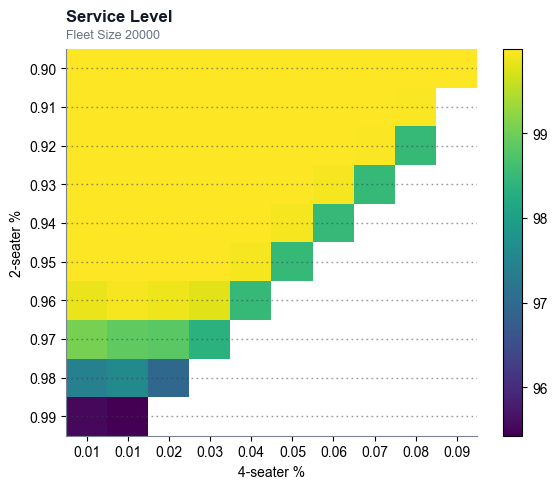

In [67]:
key = "service_level"

rows = [(pax2, pax4, stats[key]) for (pax2, pax4), stats in zip(paxes, all_stats)]

df_plot = pd.DataFrame(rows, columns=["pax2", "pax4", key])

# pivot → grid
grid = df_plot.pivot(index="pax2", columns="pax4", values=key)

# plot
plt.figure(figsize=(6, 5))
plt.imshow(grid, aspect="auto")

plt.xticks(range(len(grid.columns)), [f"{c:.2f}" for c in grid.columns])
plt.yticks(range(len(grid.index)), [f"{r:.2f}" for r in grid.index])

plt.xlabel("4-seater %")
plt.ylabel("2-seater %")
plt.colorbar()

style_plot(plt.gca(), title=key.title().replace("_", " "), subtitle=f"Fleet Size {fleet_size}")

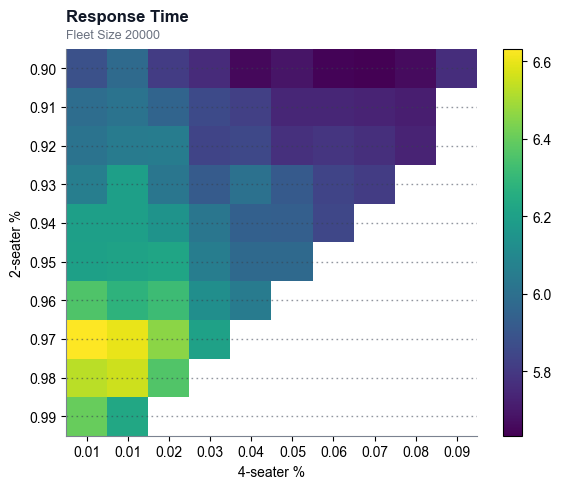

In [66]:
key = "response_time"

rows = [(pax2, pax4, stats[key]) for (pax2, pax4), stats in zip(paxes, all_stats)]

df_plot = pd.DataFrame(rows, columns=["pax2", "pax4", key])

# pivot → grid
grid = df_plot.pivot(index="pax2", columns="pax4", values=key)

# plot
plt.figure(figsize=(6, 5))
plt.imshow(grid, aspect="auto")

plt.xticks(range(len(grid.columns)), [f"{c:.2f}" for c in grid.columns])
plt.yticks(range(len(grid.index)), [f"{r:.2f}" for r in grid.index])

plt.xlabel("4-seater %")
plt.ylabel("2-seater %")
plt.colorbar()

style_plot(plt.gca(), title=key.title().replace("_", " "), subtitle=f"Fleet Size {fleet_size}")

In [22]:
df = waypoints_output[waypoints_output["state"] == 7]
df = df.sample(n=50000)
df["lat"] = np.rad2deg(df["lat"])
df["lon"] = np.rad2deg(df["lon"])

df.to_parquet("charging.parquet")
df.head()

,rider,timestamp,lat,lon,state
9526378,9704,406065,42.272877,-83.776161,7
759258,4340,40808,42.316631,-83.691277,7
6143178,9769,268087,42.305550,-83.710434,7
7615098,2797,322595,42.266163,-83.777756,7
12282032,5119,576984,42.245525,-83.683670,7


In [4]:
color1 = "#429cf5"  # blue
color2 = "#f2506e"  # red

color3 = "#003049"  # darkest blue

color4 = "#d92344"  # darker color2
color5 = "#054f75"  # lighter color3

color6 = "#e09016"  # orange
color7 = "#f5cd1d"  # yellow

styles = {
    "fm_time": SeriesStyling("FM Time", color=color1),
    "lm_time": SeriesStyling("LM Time", color=color2),
    "response_time": SeriesStyling("Response Time", color=color3),

    "fm_dist": SeriesStyling("FM Distance", color=color1),
    "lm_dist": SeriesStyling("LM Distance", color=color2),
    "predicted_lm_dist": SeriesStyling("LM Distance (Predicted)", color=color3),

    "pick_lat": SeriesStyling("Pickup Latitude", color=color1),
    "drop_lat": SeriesStyling("Drop Latitude", color=color2),

    "n_dead": SeriesStyling("Dead", color="#fff"),
    "n_idle": SeriesStyling("Idle", color=color1),
    "n_fm": SeriesStyling("First Mile", color=color2),
    "n_wait": SeriesStyling("Waiting", color=color4),
    "n_lm": SeriesStyling("Last Mile", color=color5),
    "n_drop": SeriesStyling("Dropping", color=color3),
    "n_service": SeriesStyling("Service", color=color6),
    "n_charge": SeriesStyling("Charging", color=color7),

    "dead": SeriesStyling("Dead", color="#fff"),
    "idle": SeriesStyling("Idle", color=color1),
    "fm": SeriesStyling("First Mile", color=color2),
    "pickup": SeriesStyling("Pickup", color=color4),
    "lm": SeriesStyling("Last Mile", color=color5),
    "drop": SeriesStyling("Dropping", color=color3),
    "service": SeriesStyling("Service", color=color6),
    "charge": SeriesStyling("Charging", color=color7),

    "completed": SeriesStyling("Completed", color=color3),
    "service_level": SeriesStyling("Service Level", color=color3),
}

(0.0, 11.0)

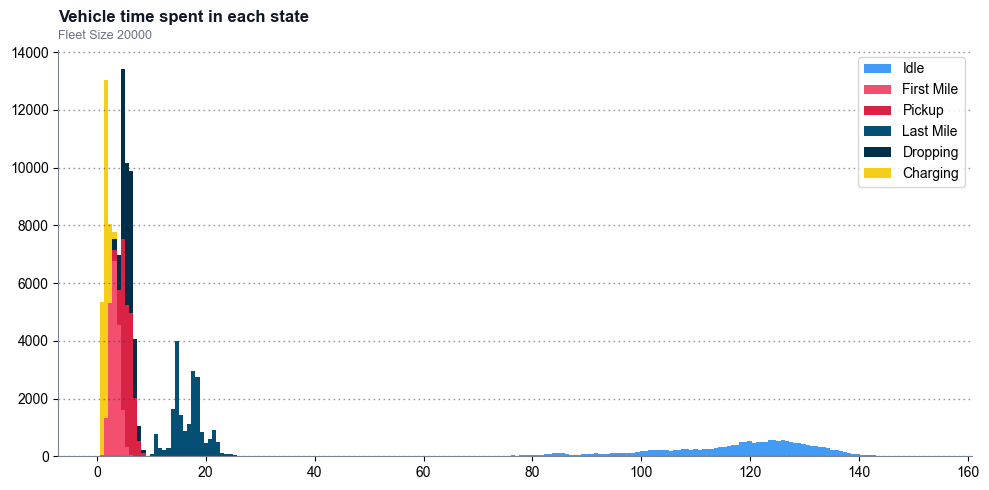

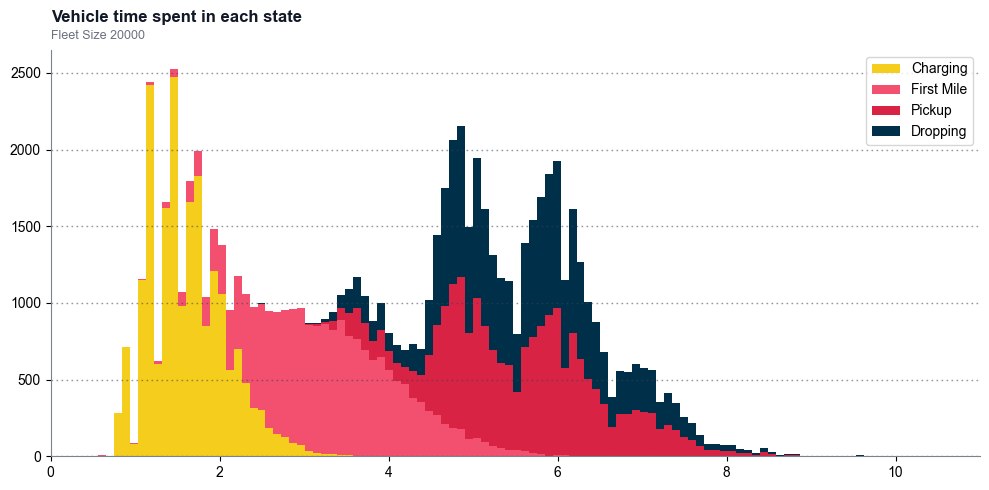

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_histogram_on_axis(rider_states / 3600, ax, styles, bins=200,
                       title="Vehicle time spent in each state", subtitle=f"Fleet Size {fleet_size}")

fig, ax = plt.subplots(figsize=(10, 5))
plot_histogram_on_axis(rider_states[["charge", "fm", "pickup", "drop"]] / 3600, ax, styles, bins=100,
                       title="Vehicle time spent in each state", subtitle=f"Fleet Size {fleet_size}")
ax.set_xlim(0, 11)

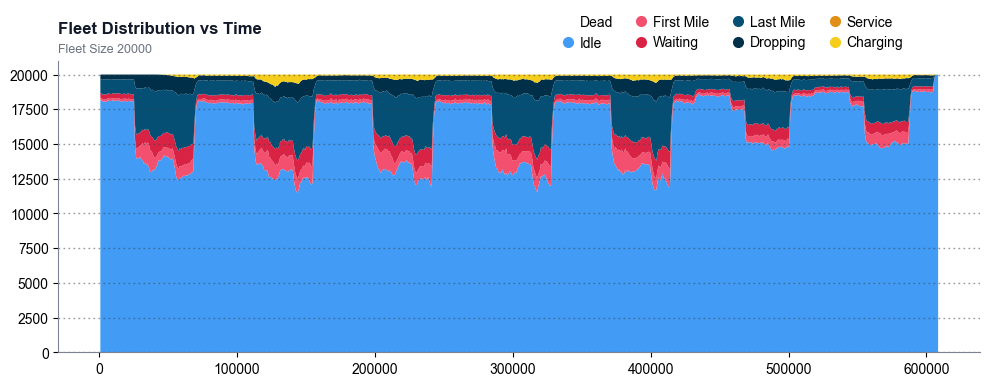

In [6]:
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(10, 4))
ax.stackplot(fleet_output.index, fleet_output.T,
             labels=[styles[c].label for c in fleet_output.columns],
             colors=[styles[c].color for c in fleet_output.columns])

handles = [
    Line2D([0], [0], marker="o", markersize=7,
           markerfacecolor=styles[c].color, markeredgecolor=styles[c].color, label=styles[c].label)
    for i, c in enumerate(fleet_output.columns)
]
ax.legend(handles=handles, bbox_to_anchor=(0.93, 1.2), ncol=4, frameon=False, handlelength=0.1)

style_plot(ax, title="Fleet Distribution vs Time", subtitle=f"Fleet Size {fleet_size}")
plt.show()

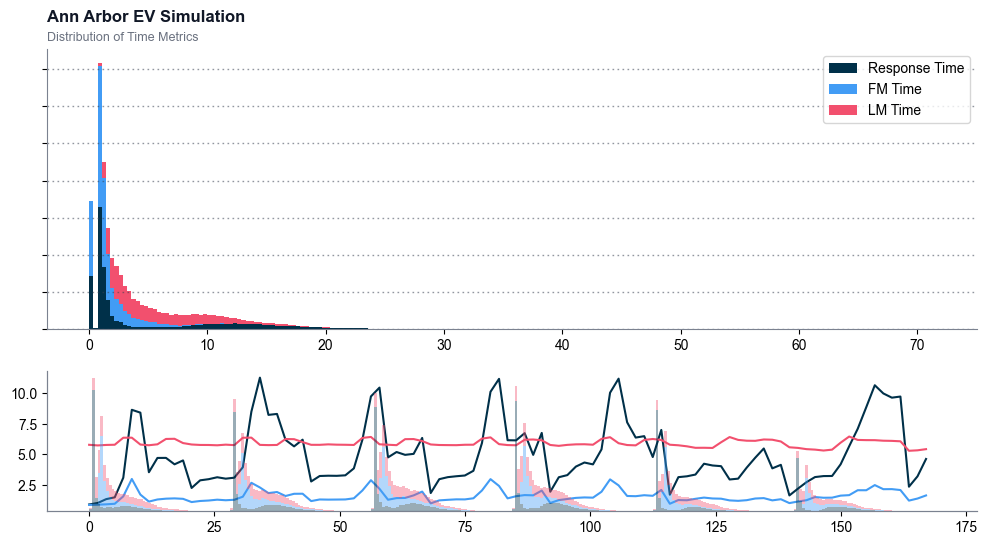

In [8]:
plot_evolving_histograms(output[["response_time", "fm_time", "lm_time"]] / 60, output["start_at"] / 3600, styles,
                         title="Ann Arbor EV Simulation", k=6, subtitle="Distribution of Time Metrics")

# Response Time (request time -> pickup time)
# FM - first mile (previous drop -> pickup time)
# LM - last mile (pickup -> drop time)

# + 4 minutes for pickup/drop

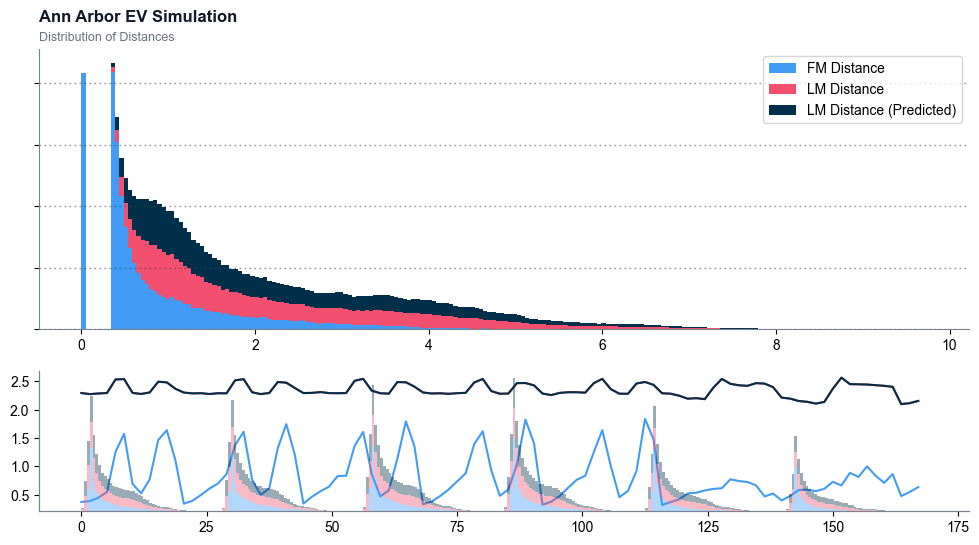

In [42]:
plot_evolving_histograms(output[["fm_dist", "lm_dist", "predicted_lm_dist"]] / 1.68, output["start_at"] / 3600, styles,
                         title="Ann Arbor EV Simulation", subtitle="Distribution of Distances", k=6)